# **1. Introduction: The Case for Cross-Learning**
- __Act 2:__ The Strategic Approach (Global Scaling). 
- **Goal:** Demonstrate how to engineer a pipeline that handles massive data (30k series) on a single machine, and reveal the "RMSE Paradox."
- Explain the concept: Learning shared patterns (e.g., "Christmas effect") across all 30,000 items simultaneously.


# **2. RAM-Optimized Data Pipeline**
- Import the custom loader: `from src.data_loader import load_global_m5`.
- Show the downcasting (`float32`, `int16`) and the logic of cutting history before Day 1100 to save memory.

In [5]:
import pandas as pd
import numpy as np
import gc
import os
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATSx
from neuralforecast.losses.pytorch import HuberLoss

In [2]:
# def reduce_mem_usage(df, verbose=True):
def read_and_squeeze(file_name, INPUT_DIR_PATH = '../data/', verbose=True):
    
    # check if the file_name is a string
    if not isinstance(file_name, str):
        raise NotImplementedError(f'Read and squeeze function is not implemented yet. {file_name} must be a string.')
    # check if the file exists at the specified path
    if not os.path.exists(INPUT_DIR_PATH+file_name):
        raise NotImplementedError(f'Read and squeeze function is not implemented yet. "{file_name}" cannot be retrieved from "{INPUT_DIR_PATH}". Check if "INPUT_DIR_PATH" is correct.')

    df = pd.read_csv(INPUT_DIR_PATH+file_name)
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics: 
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: 
        print(f'For {file_name}, mem. usage decreased from {start_mem:5.2f} Mb to {end_mem:5.2f} Mb ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df

In [6]:
# ==========================================
# 1. CONFIGURATION (RAM OPTIMIZED)
# ==========================================
HORIZON = 28
# We only load data after day 1200 (approx last 2 years). 
# Training on 5 years of history on a laptop is overkill/impossible.
START_DAY = 1200 

print(f"Loading Full M5 Dataset (Optimized for Laptop RAM)...")

# ==========================================
# 2. DATA LOADING (CHUNKED & TYPED)
# ==========================================
# We load strictly necessary columns to keep memory footprint low

# A. CALENDAR
df_cal = read_and_squeeze('calendar.csv')
# Pre-process calendar to minimize merge footprint later
df_cal['date'] = pd.to_datetime(df_cal['date'])
df_cal['d_int'] = df_cal['d'].apply(lambda x: int(x.split('_')[1]))
# Filter calendar to relevant window
df_cal = df_cal[df_cal['d_int'] >= START_DAY]
# Select only needed cols
df_cal = df_cal[['d', 'date', 'wm_yr_wk', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']]
# Downcast SNAP to int8
cols_int8 = ['snap_CA', 'snap_TX', 'snap_WI']
df_cal[cols_int8] = df_cal[cols_int8].fillna(0).astype('int8')

# B. SALES (The Big One)
print("Loading Sales...")
df_sales = read_and_squeeze('sales_train_evaluation.csv')
# Melt immediately
print("Melting (This spikes RAM)...")
id_vars = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df = pd.melt(df_sales, id_vars=id_vars, var_name='d', value_name='y')
del df_sales; gc.collect()

# Convert d to int for filtering
df['d_int'] = df['d'].apply(lambda x: int(x.split('_')[1]))

# Filter History EARLY (Save RAM before merging)
print(f"Filtering history < Day {START_DAY}...")
df = df[df['d_int'] >= START_DAY]

# C. MERGE CALENDAR
print("Merging Calendar...")
df = df.merge(df_cal, on='d', how='left')
# Drop 'd' (string) to save memory, we have 'd_int' and 'date'
df = df.drop(columns=['d'])

# D. PRICES
print("Loading & Merging Prices...")
df_prices = read_and_squeeze('sell_prices.csv')
df = df.merge(df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
del df_prices; gc.collect()

Loading Full M5 Dataset (Optimized for Laptop RAM)...
For calendar.csv, mem. usage decreased from  0.21 Mb to  0.12 Mb (41.9% reduction)
Loading Sales...
For sales_train_evaluation.csv, mem. usage decreased from 452.91 Mb to 96.13 Mb (78.8% reduction)
Melting (This spikes RAM)...
Filtering history < Day 1200...
Merging Calendar...
Loading & Merging Prices...
For sell_prices.csv, mem. usage decreased from 208.77 Mb to 130.48 Mb (37.5% reduction)


0

In [7]:
# ==========================================
# 3. FEATURE ENGINEERING (IN-PLACE)
# ==========================================
print("Engineering Features...")

# Rename for NF
df = df.rename(columns={'id': 'unique_id', 'date': 'ds'})

# Sort (Critical)
df = df.sort_values(['unique_id', 'ds']).reset_index(drop=True)

# 1. Price Filling & Masking
print("  - Processing Prices...")
df['is_available'] = (~df['sell_price'].isna()).astype('int8')
df['sell_price'] = df['sell_price'].astype('float32') # Use float32
df['sell_price'] = df.groupby('unique_id')['sell_price'].transform(lambda x: x.ffill().bfill())

# 2. Events
print("  - Processing Events...")
df['event_name_1'] = df['event_name_1'].fillna('None')
df['is_event'] = (df['event_name_1'] != 'None').astype('int8')

# 3. SNAP Logic (Dynamic)
# Since we have data from CA, TX, WI, we need a single 'snap_active' column
# that matches the state of the item.
print("  - Processing SNAP columns...")
conditions = [
    df['state_id'] == 'CA',
    df['state_id'] == 'TX',
    df['state_id'] == 'WI'
]
choices = [df['snap_CA'], df['snap_TX'], df['snap_WI']]
df['snap_active'] = np.select(conditions, choices, default=0).astype('int8')

# DROP UNUSED COLUMNS TO SAVE RAM FOR GPU
cols_to_drop = ['item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 
                'wm_yr_wk', 'event_name_1', 'snap_CA', 'snap_TX', 'snap_WI']
df = df.drop(columns=cols_to_drop)

# Final selection
Y_df = df[['unique_id', 'ds', 'y', 'sell_price', 'is_available', 'snap_active', 'is_event', 'd_int']]

print(f"Final Dataset Shape: {Y_df.shape}")
print(f"Memory Usage: {Y_df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

del df, df_cal
gc.collect()

# ==========================================
# 4. SPLIT
# ==========================================
max_d = Y_df['d_int'].max()
split_date = Y_df[Y_df['d_int'] == (max_d - HORIZON)]['ds'].min()

train_df = Y_df[Y_df['ds'] < split_date]
test_df = Y_df[Y_df['ds'] >= split_date]

futr_exog_df = test_df[['unique_id', 'ds', 'sell_price', 'is_available', 'snap_active', 'is_event']]

Engineering Features...
  - Processing Prices...
  - Processing Events...
  - Processing SNAP columns...
Final Dataset Shape: (22623580, 8)
Memory Usage: 2.51 GB


In [34]:
# ==========================================
# 4. SPLIT
# ==========================================
max_d = Y_df['d_int'].max()
split_date = Y_df[Y_df['d_int'] == (max_d - HORIZON)]['ds'].min()

train_df = Y_df[Y_df['ds'] < split_date]
test_df = Y_df[Y_df['ds'] >= split_date]

futr_exog_df = test_df[['unique_id', 'ds', 'sell_price', 'is_available', 'snap_active', 'is_event']]

In [49]:
import shutil
from pytorch_lightning.loggers import CSVLogger
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts


# ==========================================
# 5. MODEL DEFINITION (FULL DATASET MODE)
# ==========================================
print("Setting up Global N-BEATSx...")

# 1. CLEANUP OLD LOGS (Crucial for reproducible plotting)
if os.path.exists("logs/nbeats_huber_full"):
    shutil.rmtree("logs/nbeats_huber_full")



logger_huber_full = CSVLogger("logs", name="nbeats_huber_full")

common_params = dict(
    h=HORIZON,
    input_size= 370,
    scaler_type='robust',
    max_steps=5000,
    val_check_steps=60,
    early_stop_patience_steps=10,
    dropout_prob_theta=0.1,
    futr_exog_list=['sell_price', 'is_available', 'snap_active', 'is_event'],
    exclude_insample_y=False,
    accelerator='mps',
    devices=1,
    batch_size=512,
    enable_progress_bar=True
)

model_nbtx = NBEATSx(
    **common_params,
    learning_rate=1e-3, # Start here
    loss=HuberLoss(delta=1.0),
    logger=logger_huber_full,
    # 1. Add the Scheduler Class
    lr_scheduler=CosineAnnealingWarmRestarts,
    
    # 2. Configure the Scheduler
    lr_scheduler_kwargs={
        'T_0': 1000, # Restart every 1000 steps
        'T_mult': 1,
        'eta_min': 1e-6 # Minimum LR to decay to
    },
    alias='NBEATSx_Cosine'
)


nf_full = NeuralForecast(
    models=[model_nbtx],
    freq='D'
)


Seed set to 1


Setting up Global N-BEATSx...


In [50]:
# ==========================================
# SINGLE SPLIT TRAINING
# ==========================================
print("Starting Global Training...")

# val_size=28 triggers the internal validation loop using the last 28 days of train_df
nf_full.fit(df=train_df, val_size=28)

print("Global Training Complete.")

Starting Global Training...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | HuberLoss     | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.7 M  | train
-------------------------------------------------------
5.6 M     Trainable params
22.7 K    Non-trainable params
5.7 M     Total params
22.658    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Global Training Complete.


In [22]:
results_full.head()

,unique_id,ds,N-BEATSx_MQLoss_Full-median,N-BEATSx_MQLoss_Full-hi-60.0,N-BEATSx_MQLoss_Full-hi-80.0,y
0,FOODS_1_001_CA_1_evaluation,2016-04-24,1.003318,2.995964,4.254601,0
1,FOODS_1_001_CA_1_evaluation,2016-04-25,0.999178,2.398248,3.734882,2
2,FOODS_1_001_CA_1_evaluation,2016-04-26,1.000125,2.255523,3.591275,0
3,FOODS_1_001_CA_1_evaluation,2016-04-27,1.001665,2.173048,3.489421,0
4,FOODS_1_001_CA_1_evaluation,2016-04-28,1.000679,2.176245,3.444453,0


In [52]:
print("Predicting...")
forecasts = nf_full.predict(futr_df=futr_exog_df)
results_full = forecasts.merge(test_df[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='left')

rmse_full = np.sqrt(np.mean((results_full['y'] - results_full['NBEATSx_Cosine']) ** 2))

print("="*40)
print(f"FULL DATASET N-BEATSx RMSE: {rmse_full:.4f}")
print("="*40)

Predicting...


/Users/zak/anaconda3/envs/DataCamp/lib/python3.11/site-packages/neuralforecast/core.py:948: UserWarning: Dropped 30,490 unused rows from `futr_df`.
  warnings.warn(f"Dropped {dropped_rows:,} unused rows from `futr_df`.")
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Predicting: |          | 0/? [00:00<?, ?it/s]

FULL DATASET N-BEATSx RMSE: 2.2085


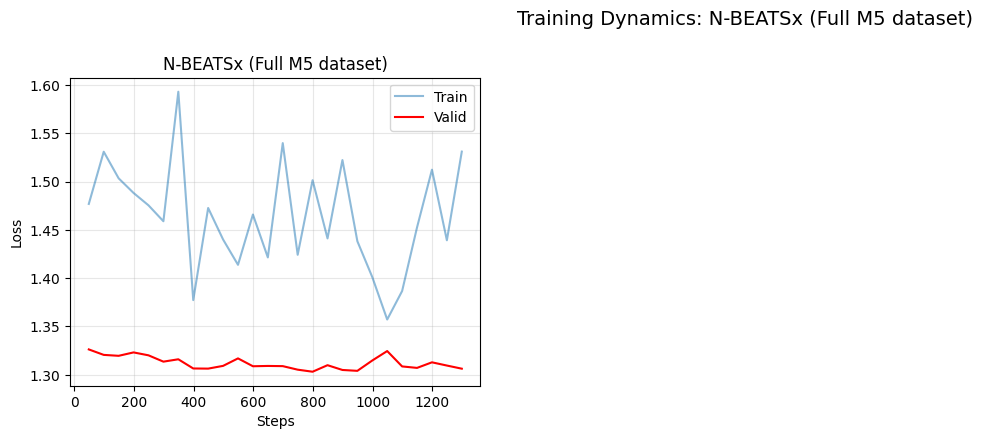

In [23]:
# ==========================================
# DIAGNOSTIC: TRAINING CURVES (FIXED)
# ==========================================
import glob
import matplotlib.pyplot as plt

def plot_learning_curves(model_name, log_folder):
    versions = sorted(glob.glob(f"logs/{log_folder}/version_*"))
    
    if not versions:
        print(f"WARNING: No logs found for {log_folder}")
        return

    plt.figure(figsize=(18, 4))
    
    for i, v_dir in enumerate(versions):
        if i >= 3: break 
        
        metrics_path = f"{v_dir}/metrics.csv"
        if os.path.exists(metrics_path):
            m_df = pd.read_csv(metrics_path)
            
            # STRATEGY: Isolate the streams
            # 1. Extract Training Data (Drop rows where train_loss_step is NaN)
            train_df = m_df[['step', 'train_loss_step']].dropna()
            
            # 2. Extract Validation Data (Drop rows where valid_loss is NaN)
            valid_df = m_df[['step', 'valid_loss']].dropna()
            
            plt.subplot(1, 3, i+1)
            
            # Plot independently
            plt.plot(train_df['step'], train_df['train_loss_step'], label='Train', alpha=0.5)
            plt.plot(valid_df['step'], valid_df['valid_loss'], label='Valid', color='red', linewidth=1.5)
            
            plt.title(f"{model_name}")
            plt.xlabel("Steps")
            plt.ylabel("Loss")
            if i == 0: plt.legend()
            plt.grid(True, alpha=0.3)
    
    plt.suptitle(f"Training Dynamics: {model_name}", fontsize=14, y=1.05)
    plt.show()

# Execute
plot_learning_curves("N-BEATSx (Full M5 dataset)", "nbeats_MQLoss_full")

In [53]:
m_df = pd.read_csv("logs/nbeats_huber_full/version_0/metrics.csv")

In [54]:
display(m_df)

,epoch,ptl/val_loss,step,train_loss_epoch,train_loss_step,valid_loss
0,0,NaN,49,NaN,1.109474,NaN
1,0,1.135042,59,NaN,NaN,1.140322
2,0,NaN,59,1.058298,NaN,NaN
3,1,NaN,99,NaN,0.899136,NaN
4,1,0.753415,119,NaN,NaN,0.757159
...,...,...,...,...,...,...
75,23,NaN,1439,0.705037,NaN,NaN
76,24,NaN,1449,NaN,0.704834,NaN
77,24,NaN,1499,NaN,0.659308,NaN
78,24,0.682976,1499,NaN,NaN,0.686411


In [55]:
train_m_df = m_df[['epoch', 'train_loss_epoch']].dropna()
# display(train_m_df)

In [56]:
valid_m_df = m_df[['epoch', 'valid_loss']].dropna()
# display(valid_m_df)

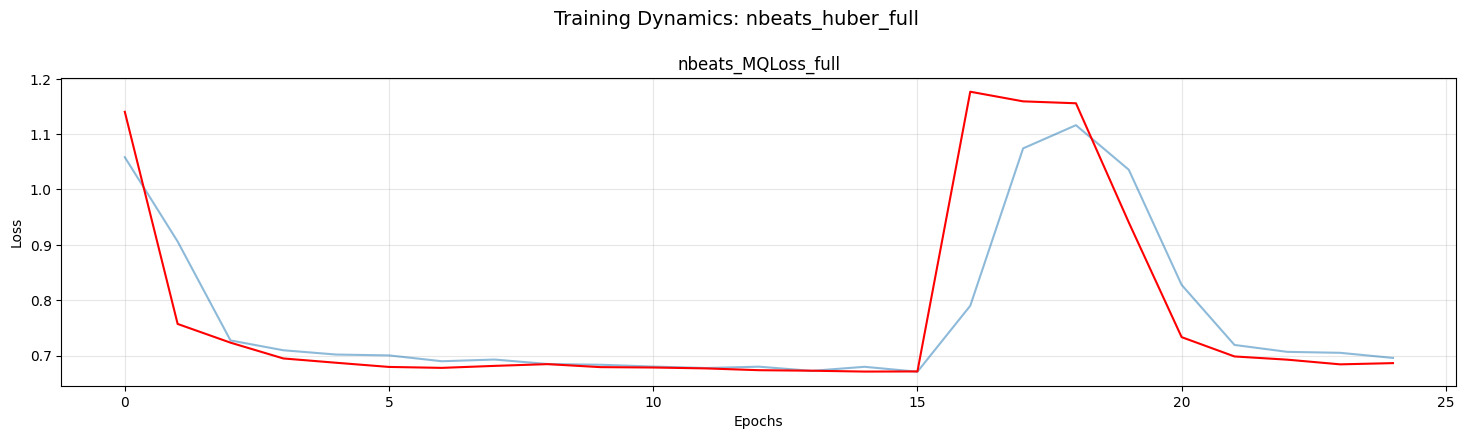

In [58]:
plt.figure(figsize=(18, 4))
plt.plot(train_m_df['epoch'], train_m_df['train_loss_epoch'], label='Train', alpha=0.5)
plt.plot(valid_m_df['epoch'], valid_m_df['valid_loss'], label='Valid', color='red', linewidth=1.5)

plt.title(f"nbeats_MQLoss_full")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)

plt.suptitle(f"Training Dynamics: nbeats_huber_full", fontsize=14, y=1.05)
plt.show()

Use MQLoss to see if this works well

In [64]:
from neuralforecast.losses.pytorch import MQLoss

# ==========================================
# 5. MODEL DEFINITION (FULL DATASET MODE)
# ==========================================
print("Setting up Global N-BEATSx...")

# 1. CLEANUP OLD LOGS (Crucial for reproducible plotting)
if os.path.exists("logs/nbeats_mqloss_stable_full"):
    shutil.rmtree("logs/nbeats_mqloss_stable_full")



logger_MQLoss_stable_full = CSVLogger("logs", name="nbeats_mqloss_stable_full")

common_params = dict(
    h=HORIZON,
    input_size=370, 
    scaler_type='robust',
    max_steps=8000,          # Give it more time
    val_check_steps=100,     # Check less frequently to speed up
    early_stop_patience_steps=15,
    dropout_prob_theta=0.2,  # Slight increase to force robust features
    futr_exog_list=['sell_price', 'is_available', 'snap_active', 'is_event'],
    exclude_insample_y=False,
    accelerator='mps',
    devices=1,
    batch_size=512,         # <--- Increased for gradient stability
    enable_progress_bar=True
)

model_mqloss_stable_full = NBEATSx(
    **common_params,
    learning_rate=5e-4,      # <--- Lowered from 1e-3 (Slower but safer)
    loss=MQLoss(quantiles=[0.5, 0.8, 0.9]), # <--- Back to the correct loss for retail
    logger=logger_MQLoss_stable_full,
    
    lr_scheduler=CosineAnnealingWarmRestarts,
    lr_scheduler_kwargs={
        'T_0': 2000,         # <--- Restart later (let it settle)
        'T_mult': 2,         # <--- Double the cycle length each time
        'eta_min': 1e-6
    },
    alias='NBEATSx_MQLoss_Stable'
)

nf_mqloss_stable_full = NeuralForecast(
    models=[model_mqloss_stable_full],
    freq='D'
)

Seed set to 1


Setting up Global N-BEATSx...


In [ ]:
# ==========================================
# SINGLE SPLIT TRAINING
# ==========================================
print("Starting Global Training...")

# val_size=28 triggers the internal validation loop using the last 28 days of train_df
nf_mqloss_stable_full.fit(df=train_df, val_size=28)

print("Global Training Complete.")

Starting Global Training...


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MQLoss        | 3      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | blocks       | ModuleList    | 5.8 M  | train
-------------------------------------------------------
5.7 M     Trainable params
22.7 K    Non-trainable params
5.8 M     Total params
23.007    Total estimated model params size (MB)
40        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
# 1. Run Prediction
fcst_df = nf_full.predict(futr_df=future_exog_df)

# fcst_df will have columns like: 
# ['ds', 'NBEATSx-median', 'NBEATSx-lo-0.8', 'NBEATSx-lo-0.9'] 
# (Note: column names depend on how NeuralForecast names them, 
# usually it's model_name or model_name-median for 0.5)

# 2. Extract the Point Forecast
# Inspect columns first to confirm the name for the 0.5 quantile
print(fcst_df.columns) 

# Let's assume the 0.5 quantile is named 'NBEATSx' or 'NBEATSx-median'
point_forecast = fcst_df['NBEATSx'] 

# 3. Compute Metrics
from neuralforecast.losses.numpy import rmse

# Calculate RMSE using ONLY the median column
nbeats_rmse = rmse(y=test_df['y'], y_hat=point_forecast)
print(f"NBEATSx RMSE: {nbeats_rmse}")

# # Calculate WRMSSE using ONLY the median column
# # (Assuming you have your WRMSSE function set up)
# nbeats_wrmsse = wrmsse_function(y_true=test_df['y'], y_pred=point_forecast)
# print(f"NBEATSx WRMSSE: {nbeats_wrmsse}")

# **3. Model A: Global N-BEATSx (The Challenger)**
- Setup the Global Model (Batch Size 1024).
- Train on full dataset.
- **Result:** Print Global RMSE (~2.36).

# **4. Model B: Global LightGBM (The Control)**
- *Critical Step:* We must train LightGBM on the *same* global data to compare fairly.
- Setup Global LightGBM (feature engineering on 30k items).
- Train (this will take the ~15 mins).
- **Result:** Print Global RMSE (~2.19).

# **5. The Conflict**
- Visualize the leaderboard.
- __Observation:__ "LightGBM has a lower RMSE (2.19 vs 2.36). Does this mean Trees win? Not necessarily. RMSE penalizes spikes in high-volume items. We need to check if the models are actually useful for the *entire* inventory."